# Exercise 4A. Classification, shallow learning, model training

The aim of exercise 4 is to learn how to:
* train shallow learning models
* use the trained model to predict an whole image
* evaluate the models accuracy
* see what features mostly contribute to the results

The task is land-use classification, based on 2 datasets: Sentinel-2 11-days mosaic and Google AlphaEarth data.

This exercise is split to 2 notebooks:
* This for model training
* `04B_shallow_classification_prediction_and_evaluation.ipynb` for models evaluation and prediction.

**You need to run this notebook twice, for the 4B to work proeperly. Change the input dataset for the second run, look for cell marked #TODO**

## Input data

3 raster files with:

* Coordinate system: Finnish ETRS-TM35FIN, EPSG:3067
* Resolution: 20m

### Labels

Multiclass classification raster: 
* 1 - forest
* 2 - fields
* 3 - water
* 0 - everything else

### Data 

**Sentinel2 mosaic**
* Date: 2021-05-22- 2021-05-31
* 10 bands: 'b02', 'b03', 'b04', 'b05', 'b06', 'b07', 'b08', 'b01', 'b11', 'b12'.
* The reflection values scaled to [0 ... 1].
      
**AlphaEarth**
* 2021
* 64 bands
* Values kept to original -127 to 127. For our tree-based models this is ok, for some other models [de-quantization](https://developers.google.com/earth-engine/guides/aef_on_gcs_readme#de-quantization) should be used.


## Results

The trained models for both datasets: 
* Random forest
* Histogram-based Gradient Boosting Classification Tree

## Main steps

1) Read data and shape it to suitable form for scikit-learn.
2) Divide the data to training, validation and test datasets using spatial blocks.
3) Undersample to balance the training dataset.
4) Train the models.
5) Use grid search to find optimal settings for model training.

## Imports and paths

In [1]:
import os, time
from imblearn.under_sampling import RandomUnderSampler
from joblib import dump, load
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show_hist
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GroupShuffleSplit
%matplotlib inline

In [2]:
# Set folders
user = os.environ.get('USER')
base_folder = os.path.join('/scratch/project_2019932/students', user, 'GeoML')
dataFolder = os.path.join(base_folder,'data', 'raster', 'pixel-wise')
outputBaseFolder= os.path.join(base_folder,'04_shallow_classification')

# Source data local paths
multiclass_classification_file = os.path.join(dataFolder, 'labels.tif')

# Available cores. 
n_jobs = len(os.sched_getaffinity(0))

In [3]:
#TODO, change the input dataset
input_data = "sentinel2"
#input_data = "alphaearth"

In [4]:
filename = "data_" + input_data + ".tif"
image_file = os.path.join(dataFolder, filename)
image_file

'/scratch/project_2019932/students/ekkylli/GeoML/data/raster/pixel-wise/data_sentinel2.tif'

Get the input data. 

* During the CSC course, copy the data to your own folder from Roihu.
* If doing this exercise outside of CSC course, run the [raster data preparations exercise](../02_raster_data_preparation) first.

In [5]:
! mkdir -p /scratch/project_2019932/raster_data /scratch/project_2019932/students/$USER/GeoML/data/raster
! test -f /scratch/project_2019932/students/$USER/GeoML/data/raster/pixel-wise/labels.tif || cp -R /scratch/project_2019932/raster_data/pixel-wise /scratch/project_2019932/students/$USER/GeoML/data/raster/

## 4.1 Read data and shape it to suitable form for scikit-learn

Read the input dataset with Rasterio and shape it to suitable form for scikit-learn.

### Data

The satellite image has 8 channels (Alphaearth 64), so rasterio reads it in as 3D data cube.

For scikit-learn we reshape the data to 2D, having in dataframe one row for each pixel. Each pixel has 8 (64) values, one for each band.

In [6]:
# Read the pixel values from .tif file as dataframe
with rasterio.open(image_file) as image_dataset:
    image_data = image_dataset.read()

# Check shape of input data
print ('Dataframe original shape, 3D: ', image_data.shape)    

Dataframe original shape, 3D:  (10, 1000, 1000)


Save number of bands for later, to be able to reshape data back to 3D.

In [7]:
no_bands_in_image = image_data.shape[0]
no_bands_in_image

10

As a mid-step transponse the axis order, so that the bands are the last. Notice how the dataframe size changes.

In [8]:
image_data2 = np.transpose(image_data, (1, 2, 0))
# Check again the data shape, now the bands should be last.
print ('Dataframe shape after transpose, 3D: ', image_data2.shape) 

Dataframe shape after transpose, 3D:  (1000, 1000, 10)


In [9]:
# Then reshape to 2D.
pixels = image_data2.reshape(-1, no_bands_in_image)
print ('Dataframe shape after transpose and reshape, 2D: ', pixels.shape) 

Dataframe shape after transpose and reshape, 2D:  (1000000, 10)


### Labels
Do the same for labels.

In [10]:
# For labels only reshape to 1D is enough.
with rasterio.open(multiclass_classification_file) as labels_src:
    labels_data = labels_src.read()
    input_labels = labels_data.reshape(-1)
    print ('Labels shape after reshape, 1D: ', input_labels.shape)

Labels shape after reshape, 1D:  (1000000,)


Notice that labels data has only one band.

In [11]:
labels_data.shape

(1, 1000, 1000)

## 4.2 Divide data to training, validation and test datasets based on spatial location

The neighboring pixels in a raster are highly correlated, i.e. there is spatial autocorrelation. We can try and mitigate this by first splitting the data into spatial blocks and then divide the data into training, validation and test based on the blocks such that data from the whole block is assigned to only one of the sets. 

In [12]:
_, H, W = image_data.shape
n_blocks_per_side = 6  # Tune this according to the distances

block_h = H // n_blocks_per_side # Divide the number of pixels in height and width into blocks 
block_w = W // n_blocks_per_side
row_idx, col_idx = np.meshgrid(np.arange(H), np.arange(W), indexing='ij') # Assign an index to each block (e.g. 0,0 is the left most upper block)
block_id = (row_idx // block_h) * n_blocks_per_side + (col_idx // block_w) # Flatten the 2D block position to one integer ranging from 0 to 42
block_id

array([[ 0,  0,  0, ...,  6,  6,  6],
       [ 0,  0,  0, ...,  6,  6,  6],
       [ 0,  0,  0, ...,  6,  6,  6],
       ...,
       [36, 36, 36, ..., 42, 42, 42],
       [36, 36, 36, ..., 42, 42, 42],
       [36, 36, 36, ..., 42, 42, 42]], shape=(1000, 1000))

Now we have raster data as a 2D dataframe (1000000, 8) and labels as a flattened vector (1000000,). Let's flatten the block_id array also. 

In [13]:
groups = block_id.reshape(-1)

Set training, validation and test data ratios, how big part of the pixels is assigned to different sets.

In [14]:
train_ratio = 0.7
validation_ratio = 0.2
test_ratio = 0.1

X = pixels
y = input_labels

Split into training, validation and test sets using Sklearn GroupShuffleSplit based on the blocks. Let's first separate test set.

In [15]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.1, random_state=2) 
rest_idx, test_idx = next(gss.split(X, y, groups=groups))

X_rest, X_test = X[rest_idx], X[test_idx]
y_rest, y_test = y[rest_idx], y[test_idx]

... and then training and validation set, keeping the neighboring pixels in the same splits.  

In [16]:
gss = GroupShuffleSplit(n_splits=1, test_size=validation_ratio/(train_ratio + validation_ratio), random_state=2)
train_idx, val_idx = next(gss.split(X, y, groups=groups))

X_train1, X_validation = X[train_idx], X[val_idx]
y_train1, y_validation = y[train_idx], y[val_idx]

Save the test data for evaluation and prediction.

In [17]:
test_data_file = input_data + "_test_data.npz"
np.savez(test_data_file,  X_test=X_test, y_test=y_test)

## 4.3 Resample to balance the dataset

The classes are very imbalanced in the dataset, so undersample the majority classes in the training set, so that all classes are represented about similar number of pixels. 
Notice that validation and test set keep the original class-distribution.

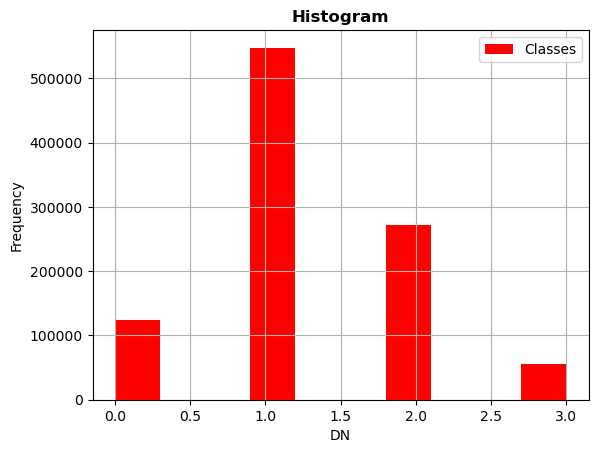

In [18]:
a = show_hist(labels_data, label='Classes')

In [19]:
rus = RandomUnderSampler(random_state=63)
x_train, y_train = rus.fit_resample(X_train1, y_train1)   
print ('Dataframe shape after undersampling of majority classes, 2D: ', x_train.shape)

Dataframe shape after undersampling of majority classes, 2D:  (199164, 10)


*How many pixels of different classes are included in training dataset?*

Notice that we lost a lot of pixel at this point, in real cases that may be undesired. See [inbalanced-learn User guide](https://imbalanced-learn.org/stable/user_guide.html#user-guide) for other options.

In [20]:
print('Labels before splitting:           ', np.unique(input_labels, return_counts=True)[1])
print('Training data before undersampling:', np.unique(y_train1, return_counts=True)[1])
print('Training data after undersampling: ', np.unique(y_train, return_counts=True)[1])
print('Validation data:                   ', np.unique(y_validation, return_counts=True)[1])
print('Test data:                         ', np.unique(y_test, return_counts=True)[1])

Labels before splitting:            [123432 547793 272454  56321]
Training data before undersampling: [ 90670 426265 211498  49791]
Training data after undersampling:  [49791 49791 49791 49791]
Validation data:                    [ 32762 121528  60956   6530]
Test data:                          [12602 78502 40630  6046]


## 4.4 Model training
### Functions for training and estimating the models

Similar functions will be used by different algorithms. Here the functions are only defined, they will be used later.

### Train the model

In [21]:
def trainModel(x_train, y_train, clf, classifierName):
    start_time = time.time()    
    clf.fit(x_train, y_train)
    print('Model training took: ', round((time.time() - start_time), 2), ' seconds')
    
    # Save the model to a file
    modelFilePath = os.path.join(outputBaseFolder, ('model_' + input_data + '_' + classifierName + '.sav'))
    dump(clf, modelFilePath) 
    return clf

### Estimate the model

Model is estimated with validation data first and later with test data. Both confusion matrix and classification report are generated.

In [22]:
def estimateModel(clf, x_test, y_test):
    test_predictions = clf.predict(x_test)
    print('Classification report: \n', classification_report(y_test, test_predictions))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, normalize='true', cmap=plt.cm.Blues)

### Random forest     

Model training took:  97.66  seconds
Classification report: 
               precision    recall  f1-score   support

           0       0.50      0.64      0.56     32762
           1       0.95      0.86      0.90    121528
           2       0.81      0.83      0.82     60956
           3       0.79      0.90      0.84      6530

    accuracy                           0.82    221776
   macro avg       0.76      0.81      0.78    221776
weighted avg       0.84      0.82      0.83    221776



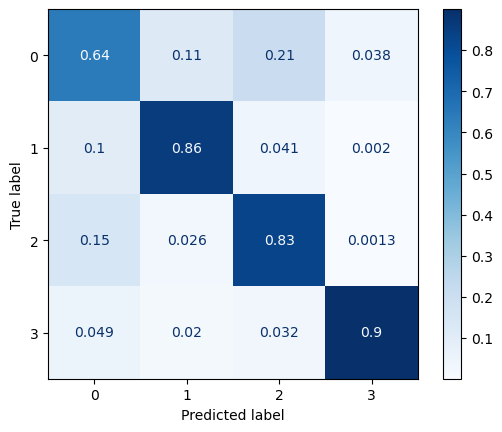

In [23]:
classifierName = 'random_forest'
# Initialize the random forest classifier and give the hyperparameters.
clf_random_forest = RandomForestClassifier(n_estimators=200, max_depth=75, random_state=0, n_jobs=n_jobs)
clf_random_forest = trainModel(x_train, y_train, clf_random_forest, classifierName)
estimateModel(clf_random_forest, X_validation, y_validation) #Validation data

*Feel free, to modify some some of the hyper-parameters above to get better results.*
And then see with test data, if the modifications help also for previously unseen data.

### Histogram-based Gradient Boosting Classification Tree

Model training took:  5.44  seconds
Classification report: 
               precision    recall  f1-score   support

           0       0.50      0.63      0.56     32762
           1       0.95      0.86      0.90    121528
           2       0.80      0.83      0.82     60956
           3       0.76      0.88      0.82      6530

    accuracy                           0.82    221776
   macro avg       0.75      0.80      0.77    221776
weighted avg       0.84      0.82      0.82    221776



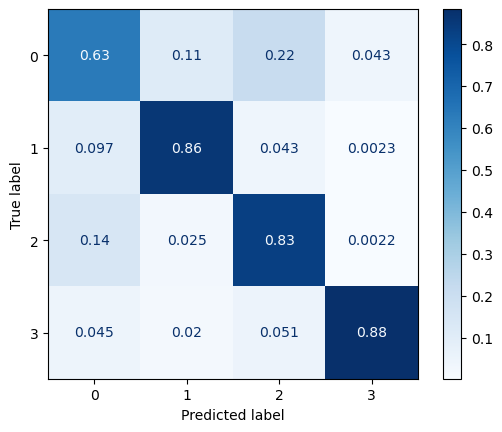

In [24]:
from sklearn.ensemble import HistGradientBoostingClassifier
classifierName = 'hist_gradient_boosting'    
clf_hist_gradient_boosting = HistGradientBoostingClassifier()
clf_hist_gradient_boosting = trainModel(x_train, y_train, clf_hist_gradient_boosting, classifierName)
estimateModel(clf_hist_gradient_boosting, X_validation, y_validation) #Validation data

## 4.5 EXTRA. Grid Search for Histogram-based Gradient Boosting Classification Tree

Different models have different settings (hyperparameters) that can be used for searching best model. Grid search is one option to automatically search for better options. For more options in hyperparameter search see [CSC machine learning guide](https://docs.csc.fi/support/tutorials/hyperparameter_search/)

Here we try different values for the Histogram-based Gradient Boosting Classification Tree model. Grid search automatically saves the best model.

*Notice, how the results are slightly improved from the first result above.*

In [25]:
classifierName = 'hist_gradient_boosting_grid'        
# Find the optimal parameters for Random Forest
param_grid = {"learning_rate": [0.1, 0.2], 'max_leaf_nodes': [70, 100]}
# Initialize the grid search, cv is the number of iterations, kept at minimum here for faster results.
grid = GridSearchCV(HistGradientBoostingClassifier(), param_grid, verbose=1, n_jobs=n_jobs, cv=2)    
# Try different options
grid = trainModel(x_train, y_train, grid, classifierName)

# Plot the best option
print('Best selected parameters: ',format(grid.best_params_))
print('Best estimator: ',format(grid.best_estimator_))

Fitting 2 folds for each of 4 candidates, totalling 8 fits
Model training took:  41.0  seconds
Best selected parameters:  {'learning_rate': 0.1, 'max_leaf_nodes': 70}
Best estimator:  HistGradientBoostingClassifier(max_leaf_nodes=70)


Classification report: 
               precision    recall  f1-score   support

           0       0.51      0.64      0.56     32762
           1       0.95      0.86      0.90    121528
           2       0.80      0.84      0.82     60956
           3       0.77      0.89      0.83      6530

    accuracy                           0.82    221776
   macro avg       0.76      0.80      0.78    221776
weighted avg       0.84      0.82      0.83    221776



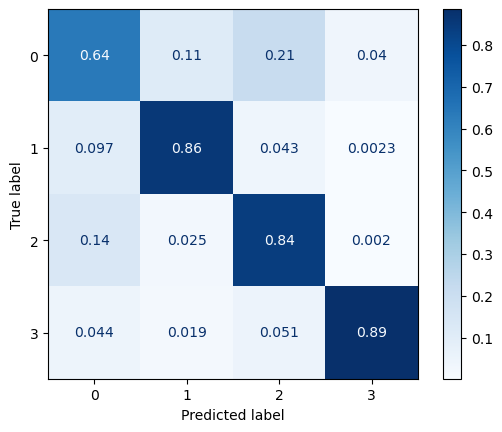

In [26]:
estimateModel(grid, X_validation, y_validation) #Validation data